# Rain Prediction Using Machine Learning

## Overview
This project explores the use of supervised machine learning algorithms to predict whether it will rain the following day based on historical weather observations. 
The workflow includes exploratory data analysis, data preprocessing, model training, hyperparameter tuning using cross-validation and performance evaluation.
Several classification algorithms are compared, including Naive Bayes, K-Nearest Neighbors, Logistic Regression, Multi-Layer Perceptron, Support Vector Machine, Decision Tree and Random Forest.

In [1]:
import pandas as pd

df = pd.read_csv("data/train-val.csv")

df.head()

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2009-03-22,Albury,14.6,30.0,0.0,NaN,NaN,NE,37.0,E,...,56.0,30.0,1014.8,1012.7,3.0,1.0,18.1,29.0,No,No
1,2009-04-15,Albury,10.7,21.9,0.0,NaN,NaN,W,63.0,NW,...,44.0,27.0,1008.2,1009.8,2.0,NaN,20.5,18.9,No,No
2,2009-04-21,Albury,5.7,21.4,0.0,NaN,NaN,ESE,17.0,ENE,...,68.0,39.0,1025.2,1020.9,NaN,NaN,12.2,20.9,No,No
3,2009-04-24,Albury,10.6,16.2,0.0,NaN,NaN,WNW,39.0,ESE,...,74.0,86.0,1008.9,1002.4,8.0,8.0,14.9,15.1,No,Yes
4,2009-05-19,Albury,3.7,19.1,0.0,NaN,NaN,SSE,19.0,NaN,...,87.0,51.0,1023.6,1019.9,NaN,NaN,7.4,18.9,No,No


## Exploratory Data Analysis

The exploratory data analysis examines the structure, feature types, class distribution, missing values and relationships between weather variables. 
The goal is to understand the dataset and identify preprocessing steps required before model training.

In [2]:
print(f"Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print("\nFeature types:")
display(df.dtypes.to_frame(name="dtype"))

Dataset shape: 10,000 rows × 23 columns

Feature types:


,dtype
Date,str
Location,str
MinTemp,float64
MaxTemp,float64
Rainfall,float64
Evaporation,float64
Sunshine,float64
WindGustDir,str
WindGustSpeed,float64
WindDir9am,str


In [3]:
categorical_cols = df.select_dtypes(include="object").columns.drop("Date")

category_summary = pd.DataFrame({
    "Feature": categorical_cols,
    "Unique categories": [df[col].nunique() for col in categorical_cols]
})

category_summary

/var/folders/cp/p3xj3yz91gvf1pt6_v2l5rhh0000gn/T/ipykernel_48025/2136961486.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include="object").columns.drop("Date")


,Feature,Unique categories
0,Location,49
1,WindGustDir,16
2,WindDir9am,16
3,WindDir3pm,16
4,RainToday,2
5,RainTomorrow,2


In [4]:
target_distribution = pd.DataFrame({
    "Count": df["RainTomorrow"].value_counts(),
    "Percentage": df["RainTomorrow"].value_counts(normalize=True).mul(100).round(2)
})

target_distribution

,Count,Percentage
RainTomorrow,,
No,7483,76.36
Yes,2317,23.64


In [5]:
numerical_cols = df.select_dtypes(include="number").columns

df[numerical_cols].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
MinTemp,9899.0,10.69,6.01,-6.8,6.5,10.4,14.7,30.3
MaxTemp,9931.0,21.52,6.55,-1.9,16.8,20.8,25.9,44.9
Rainfall,9781.0,2.21,7.53,0.0,0.0,0.0,0.8,183.4
Evaporation,5663.0,4.63,3.50,0.0,2.2,4.0,6.2,55.6
Sunshine,5175.0,7.19,3.56,0.0,4.5,8.0,10.2,13.7
WindGustSpeed,9256.0,39.15,13.82,7.0,30.0,37.0,46.0,109.0
WindSpeed9am,9883.0,13.70,8.91,0.0,7.0,13.0,19.0,67.0
WindSpeed3pm,9789.0,18.25,8.91,0.0,11.0,17.0,24.0,65.0
Humidity9am,9811.0,70.43,18.82,1.0,58.0,71.0,85.0,100.0
Humidity3pm,9689.0,52.78,20.20,1.0,39.0,53.0,66.0,100.0


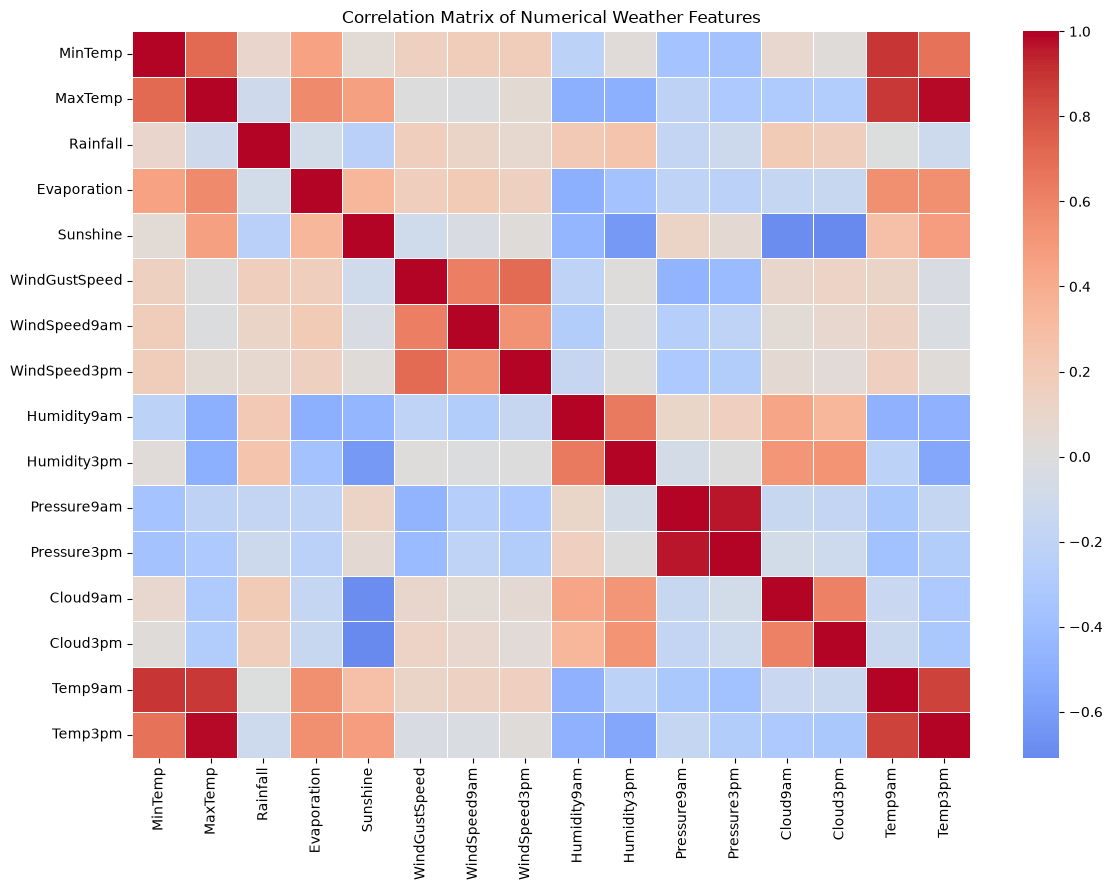

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

correlation_matrix = df[numerical_cols].corr()

plt.figure(figsize=(12, 9))
sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Correlation Matrix of Numerical Weather Features")
plt.tight_layout()
plt.show()

### Correlation Insights

The correlation matrix reveals several strong relationships among the numerical weather features. In particular, maximum temperature is strongly correlated with afternoon temperature, while minimum temperature is strongly associated with morning temperature. Morning and afternoon atmospheric pressure also exhibit a very strong positive correlation.

Moderate relationships are also observed among wind-speed variables, while sunshine shows negative associations with cloud cover and afternoon humidity. These correlations suggest that some predictors contain overlapping information, which may be relevant when interpreting model performance and feature importance.

In [7]:
missing_values = pd.DataFrame({
    "Missing values": df.isnull().sum(),
    "Percentage": (df.isnull().mean() * 100).round(2)
})

missing_values = missing_values[missing_values["Missing values"] > 0]
missing_values = missing_values.sort_values("Percentage", ascending=False)

missing_values

,Missing values,Percentage
Sunshine,4825,48.25
Evaporation,4337,43.37
Cloud3pm,4050,40.50
Cloud9am,3845,38.45
Pressure3pm,1030,10.30
Pressure9am,1027,10.27
WindDir9am,795,7.95
WindGustDir,748,7.48
WindGustSpeed,744,7.44
WindDir3pm,312,3.12


## Data Preprocessing

The dataset contains both numerical and categorical features, as well as missing values that must be handled before model training. 

The preprocessing workflow includes:

- separating the predictors from the target variable ("RainTomorrow");
- removing the "Date" feature;
- imputing missing numerical values;
- imputing missing categorical values;
- standardizing numerical features;
- one-hot encoding categorical features.

All preprocessing transformations are fitted on the training data to prevent data leakage.

In [8]:
from sklearn.model_selection import train_test_split

# Separate predictors and target
X = df.drop(columns=["Date", "RainTomorrow"])
y = df["RainTomorrow"]

# Remove observations with missing target values
valid_target = y.notna()
X = X.loc[valid_target]
y = y.loc[valid_target]

# Encode the binary target
y = y.map({"No": 0, "Yes": 1})

# Split before fitting any preprocessing transformations
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print(f"Training set: {X_train.shape}")
print(f"Validation set: {X_val.shape}")
print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True).round(3))

Training set: (6860, 21)
Validation set: (2940, 21)

Training target distribution:
RainTomorrow
0    0.764
1    0.236
Name: proportion, dtype: float64


In [9]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Identify feature types using the training set
numerical_features = X_train.select_dtypes(include="number").columns
categorical_features = X_train.select_dtypes(include=["object", "str"]).columns

# Numerical preprocessing
numerical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical preprocessing
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# Combine preprocessing steps
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numerical_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print(f"Numerical features: {len(numerical_features)}")
print(f"Categorical features: {len(categorical_features)}")

Numerical features: 16
Categorical features: 5


In [10]:
# Fit the preprocessing pipeline only on the training data
X_train_processed = preprocessor.fit_transform(X_train)

# Apply the learned transformations to the validation data
X_val_processed = preprocessor.transform(X_val)

print(f"Processed training set: {X_train_processed.shape}")
print(f"Processed validation set: {X_val_processed.shape}")

Processed training set: (6860, 115)
Processed validation set: (2940, 115)


In [11]:
import numpy as np

train_missing = np.isnan(X_train_processed.data).sum()
val_missing = np.isnan(X_val_processed.data).sum()

print(f"Missing values in processed training data: {train_missing}")
print(f"Missing values in processed validation data: {val_missing}")

Missing values in processed training data: 0
Missing values in processed validation data: 0


## Model Training & Evaluation

Seven classification algorithms are evaluated to compare different modeling approaches for predicting whether it will rain the following day:

- Gaussian Naive Bayes
- K-Nearest Neighbors
- Logistic Regression
- Multi-Layer Perceptron
- Support Vector Classifier
- Decision Tree
- Random Forest

The models are first trained using baseline configurations and evaluated on the held-out validation set. Since the target classes are imbalanced, model performance will be assessed using multiple classification metrics rather than accuracy alone.

In [12]:
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

models = {
    "Naive Bayes": GaussianNB(),
    "KNN": KNeighborsClassifier(),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "MLP": MLPClassifier(hidden_layer_sizes=(100,), max_iter=1000, random_state=42),
    "SVC": SVC(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42)
}

for name, model in models.items():
    print(f"Training {name}...")

    if name == "Naive Bayes":
        model.fit(X_train_processed.toarray(), y_train)
    else:
        model.fit(X_train_processed, y_train)

print("\nAll baseline models trained successfully.")

Training Naive Bayes...
Training KNN...
Training Logistic Regression...
Training MLP...
Training SVC...
Training Decision Tree...
Training Random Forest...

All baseline models trained successfully.


In [13]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

results = []

for name, model in models.items():

    if name == "Naive Bayes":
        y_pred = model.predict(X_val_processed.toarray())
    else:
        y_pred = model.predict(X_val_processed)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_val, y_pred),
        "Precision": precision_score(y_val, y_pred),
        "Recall": recall_score(y_val, y_pred),
        "F1 Score": f1_score(y_val, y_pred)
    })

results_df = (
    pd.DataFrame(results)
    .sort_values("F1 Score", ascending=False)
    .reset_index(drop=True)
)

results_df.round(3)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.835,0.699,0.534,0.605
1,MLP,0.814,0.612,0.583,0.597
2,SVC,0.839,0.748,0.483,0.587
3,Random Forest,0.833,0.724,0.476,0.575
4,KNN,0.812,0.648,0.450,0.531
5,Decision Tree,0.763,0.499,0.563,0.529
6,Naive Bayes,0.632,0.363,0.738,0.486


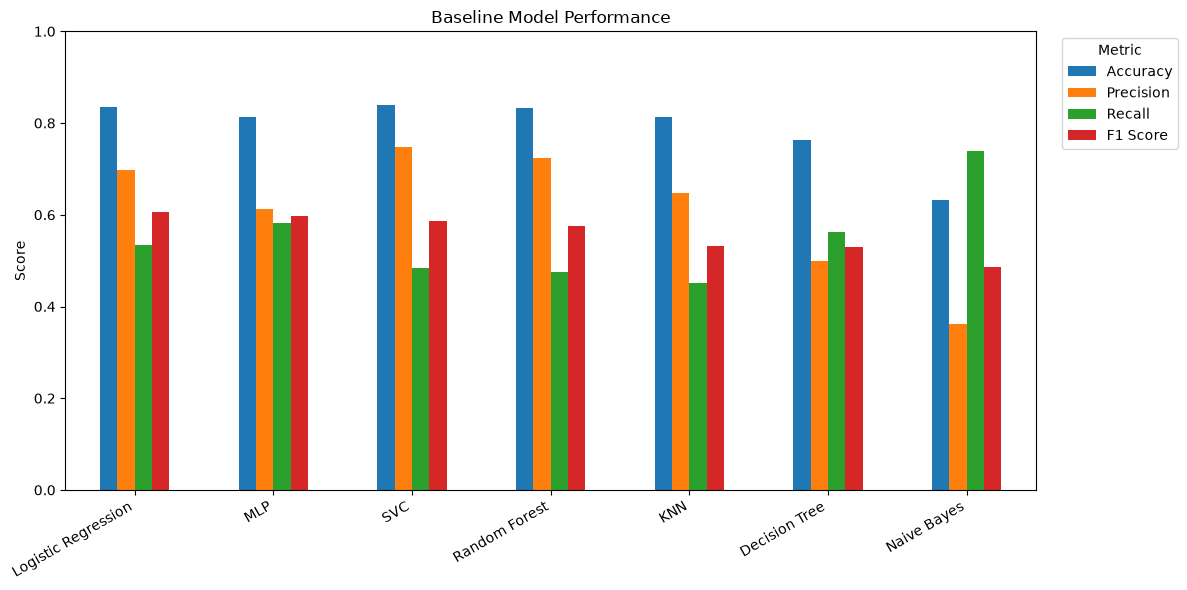

In [14]:
results_plot = results_df.set_index("Model")[
    ["Accuracy", "Precision", "Recall", "F1 Score"]
]

ax = results_plot.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Baseline Model Performance")
plt.ylabel("Score")
plt.xlabel("")
plt.ylim(0, 1)
plt.xticks(rotation=30, ha="right")
plt.legend(title="Metric", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

### Baseline Model Insights

Logistic Regression achieved the highest F1 score (0.605), providing the most balanced baseline performance between precision and recall. MLP followed closely with an F1 score of 0.597 and achieved higher recall, identifying a larger proportion of rainy days.

SVC achieved the highest accuracy (0.839) and precision (0.748), but its lower recall (0.483) indicates that it missed a larger proportion of actual rainy days.

Naive Bayes showed the opposite behavior, achieving the highest recall (0.738) but substantially lower precision (0.363). This illustrates the importance of considering multiple evaluation metrics in this imbalanced classification problem rather than relying on accuracy alone.

## Hyperparameter Tuning

Selected models are further optimized using Grid Search with 5-fold stratified cross-validation. Hyperparameter selection is based on the F1 score of the positive class, providing a balance between precision and recall for predicting rainy days.

The validation set remains completely unseen during hyperparameter selection and is used only for the final evaluation of the tuned models.

In [15]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

logistic_param_grid = {
    "C": [0.1, 1, 10],
    "class_weight": [None, "balanced"]
}

logistic_grid = GridSearchCV(
    estimator=LogisticRegression(max_iter=1000),
    param_grid=logistic_param_grid,
    scoring="f1",
    cv=cv,
    n_jobs=1
)

logistic_grid.fit(X_train_processed, y_train)

print("Best parameters:", logistic_grid.best_params_)
print(f"Best cross-validation F1: {logistic_grid.best_score_:.3f}")

Best parameters: {'C': 0.1, 'class_weight': 'balanced'}
Best cross-validation F1: 0.641


In [16]:
best_logistic = logistic_grid.best_estimator_

y_pred_tuned_lr = best_logistic.predict(X_val_processed)

tuned_lr_results = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score"],
    "Baseline": [
        accuracy_score(y_val, models["Logistic Regression"].predict(X_val_processed)),
        precision_score(y_val, models["Logistic Regression"].predict(X_val_processed)),
        recall_score(y_val, models["Logistic Regression"].predict(X_val_processed)),
        f1_score(y_val, models["Logistic Regression"].predict(X_val_processed))
    ],
    "Tuned": [
        accuracy_score(y_val, y_pred_tuned_lr),
        precision_score(y_val, y_pred_tuned_lr),
        recall_score(y_val, y_pred_tuned_lr),
        f1_score(y_val, y_pred_tuned_lr)
    ]
})

tuned_lr_results.round(3)

,Metric,Baseline,Tuned
0,Accuracy,0.835,0.786
1,Precision,0.699,0.534
2,Recall,0.534,0.754
3,F1 Score,0.605,0.625


### Logistic Regression Tuning Results

Hyperparameter tuning selected `C = 0.1` and `class_weight = "balanced"`, achieving a mean cross-validation F1 score of 0.641.

On the held-out validation set, the tuned model improved the F1 score from 0.605 to 0.625 and substantially increased recall from 0.534 to 0.754. This indicates that the tuned model identifies a considerably larger proportion of rainy days.

The improvement in recall comes at the cost of lower precision (0.699 → 0.534) and accuracy (0.835 → 0.786), illustrating the trade-off between detecting more positive cases and generating additional false-positive predictions.

In [17]:
# Load the unseen test dataset
df_test = pd.read_csv("data/test.csv")

print(f"Test set shape: {df_test.shape}")
df_test.head()

Test set shape: (4600, 23)


,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,14/08/2016,Albury,4.7,16.6,0.2,NaN,NaN,W,22.0,E,...,81.0,56.0,1029.6,1028.1,NaN,1.0,10.0,16.0,No,No
1,15/08/2016,Albury,2.2,16.8,0.0,NaN,NaN,ENE,19.0,NaN,...,100.0,56.0,1033.0,1030.1,8.0,1.0,6.5,15.7,No,No
2,26/08/2016,Albury,0.2,13.6,0.0,NaN,NaN,WNW,30.0,ESE,...,100.0,50.0,1022.9,1020.5,8.0,1.0,4.0,13.0,No,No
3,29/08/2016,Albury,3.4,18.2,0.0,NaN,NaN,NNE,26.0,NaN,...,85.0,51.0,1027.6,1024.2,6.0,3.0,10.0,16.5,No,No
4,07/09/2016,Albury,5.5,20.5,0.0,NaN,NaN,E,22.0,NaN,...,90.0,60.0,1031.2,1027.4,NaN,1.0,12.1,19.7,No,No


In [18]:
print(df_test.columns.tolist())

print("\nRainTomorrow present:", "RainTomorrow" in df_test.columns)

if "RainTomorrow" in df_test.columns:
    print("\nTarget distribution:")
    print(df_test["RainTomorrow"].value_counts(dropna=False))

['Date', 'Location', 'MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine', 'WindGustDir', 'WindGustSpeed', 'WindDir9am', 'WindDir3pm', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am', 'Temp3pm', 'RainToday', 'RainTomorrow']

RainTomorrow present: True

Target distribution:
RainTomorrow
No     3402
Yes    1066
NaN     132
Name: count, dtype: int64


## Final Evaluation on the Unseen Test Set

The final selected model is evaluated on a separate test dataset that was not used during model training, cross-validation, hyperparameter tuning, or model selection.

Rows without a known `RainTomorrow` label are excluded from the performance evaluation.

In [19]:
# Keep only test observations with a known target
test_labeled = df_test[df_test["RainTomorrow"].notna()].copy()

# Separate predictors and target
X_test = test_labeled.drop(columns=["Date", "RainTomorrow"])
y_test = test_labeled["RainTomorrow"].map({"No": 0, "Yes": 1})

# Apply the preprocessing learned exclusively from the training data
X_test_processed = preprocessor.transform(X_test)

print(f"Test samples used for evaluation: {len(y_test)}")
print(f"Processed test set shape: {X_test_processed.shape}")

print("\nTest target distribution:")
print(y_test.value_counts(normalize=True).round(3))

Test samples used for evaluation: 4468
Processed test set shape: (4468, 115)

Test target distribution:
RainTomorrow
0    0.761
1    0.239
Name: proportion, dtype: float64


In [20]:
# Predictions on the unseen test set
y_test_pred_baseline = models["Logistic Regression"].predict(X_test_processed)
y_test_pred_tuned = best_logistic.predict(X_test_processed)

test_results = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score"],
    "Baseline": [
        accuracy_score(y_test, y_test_pred_baseline),
        precision_score(y_test, y_test_pred_baseline),
        recall_score(y_test, y_test_pred_baseline),
        f1_score(y_test, y_test_pred_baseline)
    ],
    "Tuned": [
        accuracy_score(y_test, y_test_pred_tuned),
        precision_score(y_test, y_test_pred_tuned),
        recall_score(y_test, y_test_pred_tuned),
        f1_score(y_test, y_test_pred_tuned)
    ]
})

test_results.round(3)

,Metric,Baseline,Tuned
0,Accuracy,0.845,0.801
1,Precision,0.732,0.558
2,Recall,0.551,0.795
3,F1 Score,0.628,0.656


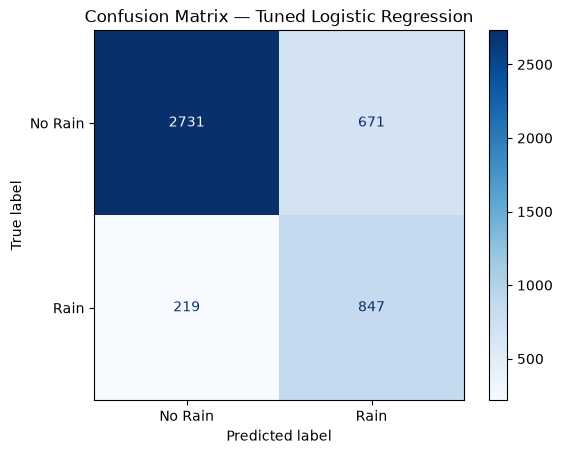

In [21]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_test_pred_tuned,
    display_labels=["No Rain", "Rain"],
    cmap="Blues"
)

plt.title("Confusion Matrix — Tuned Logistic Regression")
plt.show()

### Final Test Set Results

The tuned Logistic Regression model achieved an F1 score of **0.656** on the unseen test set, compared with **0.628** for the baseline model. Recall increased substantially from **0.551 to 0.795**, indicating that the tuned model identified a much larger proportion of actual rainy days.

The confusion matrix shows that the model correctly identified **847 of the 1,066 rainy days**, while missing **219**. However, the increased sensitivity to rainfall resulted in **671 false-positive predictions**, which explains the reduction in precision from 0.732 to 0.558.

Overall, hyperparameter tuning shifted the model toward greater sensitivity to the minority class. This improved recall and F1 score at the expense of accuracy and precision, demonstrating the trade-off involved in classification under class imbalance.